In [ ]:
import numpy as np
import cv2
import pickle
import glob
import os
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from ipywidgets import interact, FloatSlider, IntSlider

IMAGE_DIR   = "/home/aayushi/Documents/Lepton/turntable/proc"   # folder with .tiff files
PARAMS_FILE = "camera_params.npz"   # K and dist
POSES_FILE  = "camera_poses.pkl"    

# Voxel grid (metres) — adjust to your object size
VOXEL_GRID_SIZE  = 96          
VOXEL_EXTENT_XY  = 0.23         
VOXEL_EXTENT_Z   = 0.30         
VOXEL_Z_OFFSET   = 0.00         # raise grid if object bottom not at world Z=0

print("Config OK")

Config OK


In [2]:
# Camera intrinsics 
cam = np.load(PARAMS_FILE)
K   = cam["K"].astype(np.float64)
dist = cam["dist"].astype(np.float64)
print("K:\n", K)
print("dist:", dist)

#  Camera poses 
with open(POSES_FILE, "rb") as f:
    poses = pickle.load(f)

R_all = poses["R_world_to_cam"]   # (N,3,3)
t_all = poses["t_world_to_cam"]   # (N,3)
num_views = poses["num_views"]
print(f"Loaded {num_views} camera poses")

# Images 
image_paths = sorted(glob.glob(os.path.join(IMAGE_DIR, "*.tiff")))
if not image_paths:
    image_paths = sorted(glob.glob(os.path.join(IMAGE_DIR, "*.tif")))
assert len(image_paths) > 0, f"No .tiff files found in {IMAGE_DIR}"
assert len(image_paths) == num_views, (
    f"Image count ({len(image_paths)}) != pose count ({num_views}). "
    "Make sure files sort in the same order as the poses."
)
print(f"Found {len(image_paths)} images")
print("First image:", image_paths[0])

K:
 [[102.91792913   0.          87.27122227]
 [  0.         102.42992317  51.08259919]
 [  0.           0.           1.        ]]
dist: [[-0.34987549  0.14901673  0.000854   -0.00384354 -0.04705683]]
Loaded 32 camera poses
Found 32 images
First image: /home/aayushi/Documents/Lepton/turntable/proc/cap_00.tiff


In [3]:
def load_image(path):
    """Load and undistort a TIFF image."""
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    assert img is not None, f"Could not read {path}"
    img = cv2.undistort(img, K, dist)
    return img

# Method A: Otsu threshold on grayscale 
def silhouette_otsu(img, invert=False):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    _, mask = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    if invert:
        mask = cv2.bitwise_not(mask)
    return mask

# Method B: Manual brightness threshold 
def silhouette_threshold(img, thresh=80, invert=False):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    _, mask = cv2.threshold(blur, thresh, 255, cv2.THRESH_BINARY)
    if invert:
        mask = cv2.bitwise_not(mask)
    return mask

# Method C: HSV saturation / hue range (good for coloured objects) 
def silhouette_hsv(img, h_lo=0, h_hi=180, s_lo=30, v_lo=30):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    lower = np.array([h_lo, s_lo, v_lo])
    upper = np.array([h_hi, 255, 255])
    mask  = cv2.inRange(hsv, lower, upper)
    return mask

def clean_mask(mask, morph_k=5):
    """Morphological open+close to remove noise and fill small holes."""
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (morph_k, morph_k))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  k)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k)
    mask = cv2.dilate(mask, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3)))
    return mask

print("Silhouette functions defined")

Silhouette functions defined


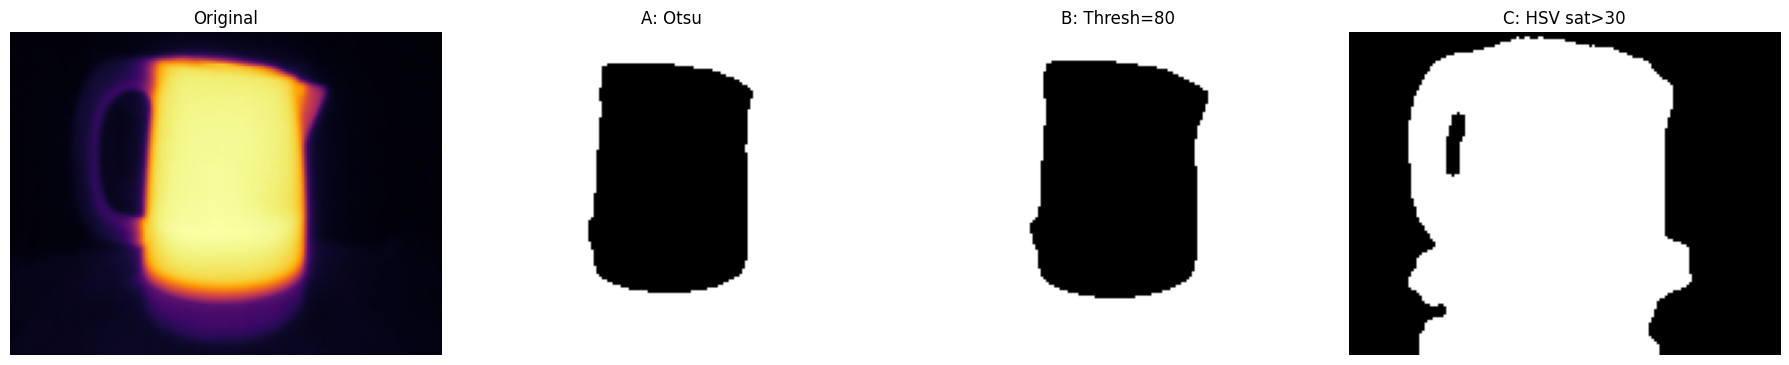

In [4]:
# Preview silhouettes on a sample image 
SAMPLE_IDX = 0   # change to inspect other views
img_sample = load_image(image_paths[SAMPLE_IDX])

masks = {
    "A: Otsu"            : clean_mask(silhouette_otsu(img_sample, invert=True)),
    "B: Thresh=80"       : clean_mask(silhouette_threshold(img_sample, thresh=80, invert=True)),
    "C: HSV sat>30"      : clean_mask(silhouette_hsv(img_sample)),
}

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].imshow(cv2.cvtColor(img_sample, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original")
for ax, (title, m) in zip(axes[1:], masks.items()):
    ax.imshow(m, cmap="gray")
    ax.set_title(title)
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# Interactive slider for Method B threshold 
@interact(
    thresh=IntSlider(min=10, max=250, step=5, value=80, description="Threshold"),
    morph_k=IntSlider(min=1, max=21, step=2, value=5, description="Morph kernel"),
    invert=True,
    view_idx=IntSlider(min=0, max=num_views-1, step=1, value=0, description="View")
)
def preview_thresh(thresh, morph_k, invert, view_idx):
    img = load_image(image_paths[view_idx])
    mask = clean_mask(silhouette_threshold(img, thresh=thresh, invert=invert), morph_k=morph_k)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Original")
    axes[1].imshow(mask, cmap="gray")
    axes[1].set_title(f"Mask (thresh={thresh}, morph={morph_k}, inv={invert})")
    for ax in axes: ax.axis("off")
    plt.tight_layout(); plt.show()

interactive(children=(IntSlider(value=80, description='Threshold', max=250, min=10, step=5), IntSlider(value=5…

In [6]:
SILHOUETTE_METHOD = 'threshold'

# Parameters for the chosen method — tune from slider above
THRESH_VALUE  = 15      # for 'threshold'
THRESH_INVERT = False    # True = object is darker than background
MORPH_K       = 5       # morphological cleanup kernel size

def get_silhouette(img):
    if SILHOUETTE_METHOD == 'otsu':
        m = silhouette_otsu(img, invert=THRESH_INVERT)
    elif SILHOUETTE_METHOD == 'threshold':
        m = silhouette_threshold(img, thresh=THRESH_VALUE, invert=THRESH_INVERT)
    elif SILHOUETTE_METHOD == 'hsv':
        m = silhouette_hsv(img)
    else:
        raise ValueError(f"Unknown method: {SILHOUETTE_METHOD}")
    return clean_mask(m, morph_k=MORPH_K)

print(f"Using method: {SILHOUETTE_METHOD}")

Using method: threshold


In [7]:
# Build voxel grid 
N  = VOXEL_GRID_SIZE
xs = np.linspace(-VOXEL_EXTENT_XY, VOXEL_EXTENT_XY, N)
ys = np.linspace(-VOXEL_EXTENT_XY, VOXEL_EXTENT_XY, N)
zs = np.linspace(VOXEL_Z_OFFSET,   VOXEL_Z_OFFSET + VOXEL_EXTENT_Z, N)

Xg, Yg, Zg = np.meshgrid(xs, ys, zs, indexing='ij')  # (N,N,N) each
ones = np.ones_like(Xg)
# World-space voxel centres: shape (4, N^3)
pts_world = np.stack([Xg.ravel(), Yg.ravel(), Zg.ravel(), ones.ravel()], axis=0)

# Boolean occupancy: start with all voxels filled
occupied = np.ones(N * N * N, dtype=bool)
occ_volume = occupied.reshape(N, N, N)
print(f"Voxel grid: {N}^3 = {N**3:,} voxels")
print(f"XY extent: +/-{VOXEL_EXTENT_XY} m   Z: {VOXEL_Z_OFFSET}-{VOXEL_Z_OFFSET+VOXEL_EXTENT_Z} m")

Voxel grid: 96^3 = 884,736 voxels
XY extent: +/-0.23 m   Z: 0.0-0.3 m


In [8]:
# Carving loop 
img0     = load_image(image_paths[0])
img_h, img_w = img0.shape[:2]

for i in range(num_views):
    R = R_all[i]   # (3,3)
    t = t_all[i]   # (3,)

    # Project world points into camera pixel coordinates
    # p_cam = R @ p_world + t
    p_cam = R @ pts_world[:3] + t[:, None]   # (3, N^3)

    # Keep only voxels in front of the camera
    in_front = p_cam[2] > 0

    # Perspective divide + apply K
    u = (K[0, 0] * p_cam[0] / p_cam[2] + K[0, 2])  # (N^3,)
    v = (K[1, 1] * p_cam[1] / p_cam[2] + K[1, 2])

    # Round to pixel
    ui = np.round(u).astype(int)
    vi = np.round(v).astype(int)

    # Valid pixel range
    in_frame = (ui >= 0) & (ui < img_w) & (vi >= 0) & (vi < img_h)
    valid = in_front & in_frame

    # Load + undistort silhouette
    img  = load_image(image_paths[i])
    mask = get_silhouette(img)  # 255 = object, 0 = background

    # For valid projected voxels, look up silhouette value
    sil_vals = np.zeros(N * N * N, dtype=np.uint8)
    sil_vals[valid] = mask[vi[valid], ui[valid]]

    # Carve: if a voxel projects outside the silhouette → remove it
    carve = valid & (sil_vals == 0)
    occupied[carve] = False

    pct = occupied.sum() / (N**3) * 100
    print(f"  View {i+1:2d}/{num_views}  remaining voxels: {occupied.sum():7,}  ({pct:.1f}%)")

occ_volume = occupied.reshape(N, N, N)
print(f"\nCarving done. Final occupancy: {occupied.sum():,} voxels ({occupied.mean()*100:.1f}%)")

  View  1/32  remaining voxels: 677,580  (76.6%)
  View  2/32  remaining voxels: 641,901  (72.6%)
  View  3/32  remaining voxels: 614,552  (69.5%)
  View  4/32  remaining voxels: 593,946  (67.1%)
  View  5/32  remaining voxels: 575,522  (65.1%)
  View  6/32  remaining voxels: 549,467  (62.1%)
  View  7/32  remaining voxels: 531,593  (60.1%)
  View  8/32  remaining voxels: 509,939  (57.6%)
  View  9/32  remaining voxels: 478,184  (54.0%)
  View 10/32  remaining voxels: 434,961  (49.2%)
  View 11/32  remaining voxels: 431,126  (48.7%)
  View 12/32  remaining voxels: 426,938  (48.3%)
  View 13/32  remaining voxels: 419,512  (47.4%)
  View 14/32  remaining voxels: 407,247  (46.0%)
  View 15/32  remaining voxels: 393,774  (44.5%)
  View 16/32  remaining voxels: 382,255  (43.2%)
  View 17/32  remaining voxels: 364,015  (41.1%)
  View 18/32  remaining voxels: 348,204  (39.4%)
  View 19/32  remaining voxels: 329,870  (37.3%)
  View 20/32  remaining voxels: 314,715  (35.6%)
  View 21/32  remain

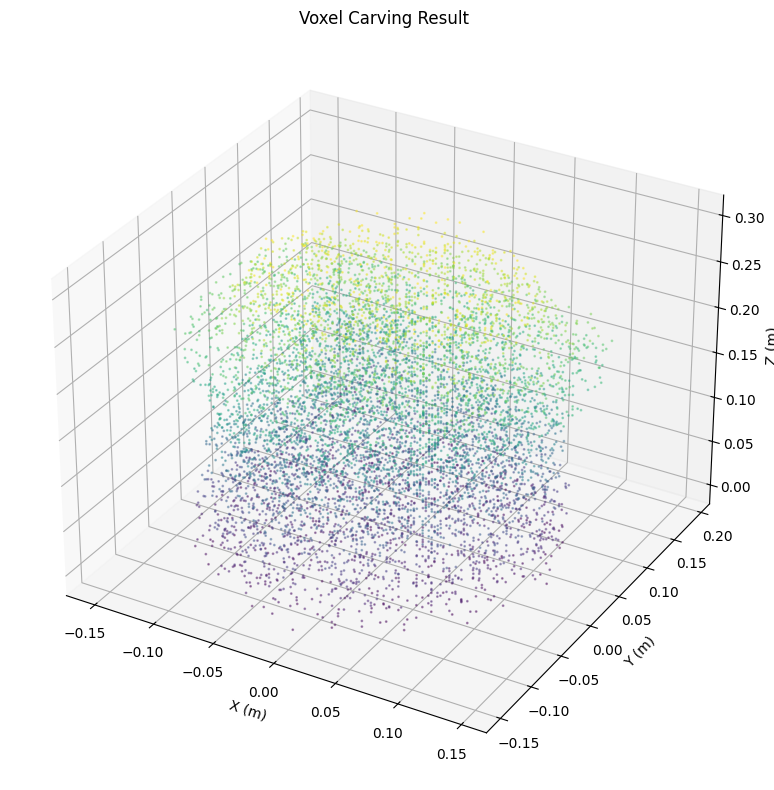

In [9]:
# 3-D scatter of occupied voxel centres 
# Subsample if large to keep the plot responsive
MAX_POINTS = 8000

occ_idx = np.argwhere(occ_volume)   # (M,3) indices
if len(occ_idx) > MAX_POINTS:
    sel = np.random.choice(len(occ_idx), MAX_POINTS, replace=False)
    occ_idx = occ_idx[sel]

# Convert indices back to world coords
ox = xs[occ_idx[:, 0]]
oy = ys[occ_idx[:, 1]]
oz = zs[occ_idx[:, 2]]

fig = plt.figure(figsize=(8, 8))
ax  = fig.add_subplot(111, projection='3d')
ax.scatter(ox, oy, oz, s=1, c=oz, cmap='viridis', alpha=0.4)
ax.set_xlabel("X (m)"); ax.set_ylabel("Y (m)"); ax.set_zlabel("Z (m)")
ax.set_title("Voxel Carving Result")
plt.tight_layout()
plt.show()

In [ ]:

@interact(
    z_slice=IntSlider(min=0, max=N-1, step=1, value=N//2, description="Z slice"),
    y_slice=IntSlider(min=0, max=N-1, step=1, value=N//2, description="Y slice"),
    x_slice=IntSlider(min=0, max=N-1, step=1, value=N//2, description="X slice"),
)
def show_slices(z_slice, y_slice, x_slice):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].imshow(occ_volume[:, :, z_slice].T, origin='lower', cmap='gray',
                   extent=[xs[0], xs[-1], ys[0], ys[-1]])
    axes[0].set_title(f"XY plane  z={zs[z_slice]:.3f} m")
    axes[0].set_xlabel("X"); axes[0].set_ylabel("Y")

    axes[1].imshow(occ_volume[:, y_slice, :].T, origin='lower', cmap='gray',
                   extent=[xs[0], xs[-1], zs[0], zs[-1]])
    axes[1].set_title(f"XZ plane  y={ys[y_slice]:.3f} m")
    axes[1].set_xlabel("X"); axes[1].set_ylabel("Z")

    axes[2].imshow(occ_volume[x_slice, :, :].T, origin='lower', cmap='gray',
                   extent=[ys[0], ys[-1], zs[0], zs[-1]])
    axes[2].set_title(f"YZ plane  x={xs[x_slice]:.3f} m")
    axes[2].set_xlabel("Y"); axes[2].set_ylabel("Z")

    plt.tight_layout(); plt.show()

interactive(children=(IntSlider(value=48, description='Z slice', max=95), IntSlider(value=48, description='Y s…

In [11]:
# Save occupancy grid as numpy array 
np.save("voxel_grid.npy", occ_volume)
print("Saved occ_volume to voxel_grid.npy  shape:", occ_volume.shape)

Saved occ_volume to voxel_grid.npy  shape: (96, 96, 96)


In [12]:
#  Export as PLY point cloud 
def save_ply(filename, points):
    """Write Nx3 float array to an ASCII PLY file."""
    header = (
        "ply\n"
        "format ascii 1.0\n"
        f"element vertex {len(points)}\n"
        "property float x\n"
        "property float y\n"
        "property float z\n"
        "end_header\n"
    )
    with open(filename, 'w') as f:
        f.write(header)
        for p in points:
            f.write(f"{p[0]:.6f} {p[1]:.6f} {p[2]:.6f}\n")
    print(f"Saved {len(points)} points to {filename}")

occ_idx_full = np.argwhere(occ_volume)
pts_world_occ = np.column_stack([
    xs[occ_idx_full[:, 0]],
    ys[occ_idx_full[:, 1]],
    zs[occ_idx_full[:, 2]],
])
save_ply("voxel_cloud.ply", pts_world_occ)

Saved 235370 points to voxel_cloud.ply


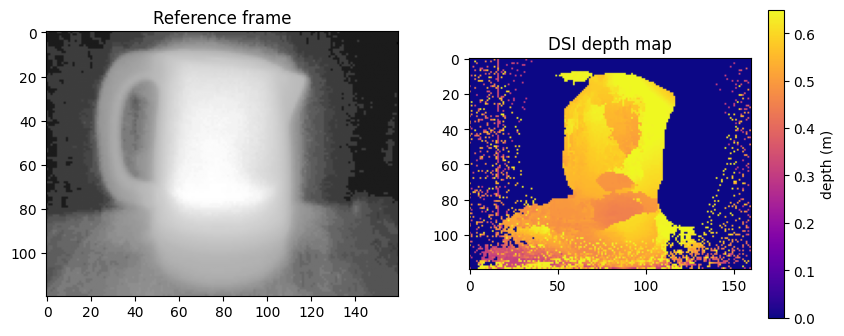

In [13]:
import numpy as np
import cv2
import pickle

with open("camera_poses.pkl", "rb") as f:
    poses = pickle.load(f)

R_all = poses["R_world_to_cam"]  # (32,3,3)
t_all = poses["t_world_to_cam"]  # (32,3)

# Load + equalise all images
imgs = []
for path in image_paths:
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.undistort(img, K, dist)
    img = cv2.equalizeHist(img)  # critical for AGC
    imgs.append(img.astype(np.float32) / 255.0)

H, W = imgs[0].shape
REF = 0  # reference frame index

# Depth sweep range — in metres, along ray from reference camera
D_MIN, D_MAX, D_STEPS = 0.30, 0.65, 64
depths = np.linspace(D_MIN, D_MAX, D_STEPS)

# DSI: cost volume, shape (H, W, D_STEPS)
DSI = np.zeros((H, W, D_STEPS), dtype=np.float32)

# Reference camera
R_R = R_all[REF]
t_R = t_all[REF]
# Camera centre of reference in world
C_R = -R_R.T @ t_R  # (3,)

for di, d in enumerate(depths):
    cost_accum = np.zeros((H, W), dtype=np.float32)
    count      = np.zeros((H, W), dtype=np.float32)

    # Back-project every reference pixel at depth d to world space
    # p_world = R_R^T @ (d * K^-1 @ [u,v,1]^T - t_R)  ... but easier:
    # p_cam_R = d * normalised ray in camera frame
    u_grid, v_grid = np.meshgrid(np.arange(W), np.arange(H))
    # normalised image coords
    ray_x = (u_grid - K[0,2]) / K[0,0]
    ray_y = (v_grid - K[1,2]) / K[1,1]
    ray_z = np.ones((H, W))
    # scale to depth d (Euclidean along Z axis of camera)
    p_cam_R = np.stack([ray_x * d, ray_y * d, ray_z * d], axis=-1)  # (H,W,3)

    # Transform to world
    p_world = (R_R.T @ (p_cam_R.reshape(-1,3).T - t_R[:,None])).T  # (H*W, 3)

    for k in range(len(imgs)):
        if k == REF:
            continue

        # Project world points into camera k
        p_cam_k = (R_all[k] @ p_world.T + t_all[k][:,None])  # (3, H*W)
        zk = p_cam_k[2]
        valid = zk > 0

        u_k = (K[0,0] * p_cam_k[0] / zk + K[0,2]).reshape(H, W)
        v_k = (K[1,1] * p_cam_k[1] / zk + K[1,2]).reshape(H, W)

        # Sample image k at projected coords (bilinear)
        map_u = u_k.astype(np.float32)
        map_v = v_k.astype(np.float32)
        sampled = cv2.remap(imgs[k], map_u, map_v,
                            interpolation=cv2.INTER_LINEAR,
                            borderMode=cv2.BORDER_CONSTANT, borderValue=np.nan)

        # Photometric error (L1)
        err = np.abs(imgs[REF] - sampled)
        in_bounds = (map_u >= 0) & (map_u < W-1) & (map_v >= 0) & (map_v < H-1)
        cost_accum[in_bounds] += err[in_bounds]
        count[in_bounds] += 1

    # Average cost over all cameras that saw this point
    valid_count = count > 0
    DSI[:, :, di][valid_count] = cost_accum[valid_count] / count[valid_count]
    DSI[:, :, di][~valid_count] = np.inf  # unseen = bad

# Extract depth map: winner-takes-all (min cost per pixel)
best_d_idx = np.argmin(DSI, axis=2)
depth_map  = depths[best_d_idx]
# Mask out pixels where min cost is still too high (no good match)
min_cost   = DSI[np.arange(H)[:,None], np.arange(W)[None,:], best_d_idx]
depth_map[min_cost > 0.15] = 0  # tune this threshold

# Visualise
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.subplot(121); plt.imshow(imgs[REF], cmap='gray'); plt.title('Reference frame')
plt.subplot(122); plt.imshow(depth_map, cmap='plasma'); plt.colorbar(label='depth (m)')
plt.title('DSI depth map'); plt.show()

In [ ]:
from scipy.ndimage import uniform_filter

def smooth_dsi_cost(DSI, imgs_ref, lambda_s=0.1):
    """Apply gradient-weighted smoothness to each depth slice of the DSI."""
    H, W, D = DSI.shape
    
    # Image gradient magnitude of reference frame (edge detector)
    grad_x = cv2.Sobel(imgs[REF], cv2.CV_32F, 1, 0, ksize=3)
    grad_y = cv2.Sobel(imgs[REF], cv2.CV_32F, 0, 1, ksize=3)
    grad_mag = np.sqrt(grad_x**2 + grad_y**2)
    
    # rho_I: decreasing function of gradient — low at edges, high in flat regions
    # high gradient = depth discontinuity likely = don't smooth across it
    rho = np.exp(-grad_mag / 0.1)  # tune 0.1: smaller = sharper edges preserved
    
    DSI_smoothed = DSI.copy()
    for di in range(D):
        slice_cost = DSI[:, :, di]
        # Smoothness penalty: penalise depth variation, weighted by rho
        # Approximate with a guided filter or weighted Gaussian
        smoothed = cv2.ximgproc.guidedFilter(
            guide=imgs[REF],
            src=slice_cost,
            radius=3,
            eps=0.01
        )
        DSI_smoothed[:, :, di] = slice_cost + lambda_s * (1 - rho) * smoothed
    
    return DSI_smoothed

def smooth_dsi_simple(DSI, lambda_s=0.15):
    from scipy.ndimage import gaussian_filter
    DSI_smoothed = DSI.copy()
    grad_x = cv2.Sobel(imgs[REF], cv2.CV_32F, 1, 0)
    grad_y = cv2.Sobel(imgs[REF], cv2.CV_32F, 0, 1)
    rho = np.exp(-(grad_x**2 + grad_y**2) / 0.05)
    for di in range(D_STEPS):
        smoothed = gaussian_filter(DSI[:,:,di], sigma=1.5)
        DSI_smoothed[:,:,di] += lambda_s * rho * smoothed
    return DSI_smoothed

DSI_smooth = smooth_dsi_simple(DSI, lambda_s=0.15)
best_d_idx = np.argmin(DSI_smooth, axis=2)
depth_map  = depths[best_d_idx]
min_cost   = DSI_smooth[np.arange(H)[:,None], np.arange(W)[None,:], best_d_idx]
depth_map[min_cost > 0.15] = 0

In [15]:
def compute_depth_map(ref_idx, imgs, K, R_all, t_all, 
                      D_MIN=0.30, D_MAX=0.65, D_STEPS=64,
                      cost_thresh=0.15, lambda_s=0.15):
    depths = np.linspace(D_MIN, D_MAX, D_STEPS)
    H, W = imgs[ref_idx].shape
    DSI = np.full((H, W, D_STEPS), np.inf, dtype=np.float32)

    R_R, t_R = R_all[ref_idx], t_all[ref_idx]
    u_grid, v_grid = np.meshgrid(np.arange(W), np.arange(H))
    ray_x = (u_grid - K[0,2]) / K[0,0]
    ray_y = (v_grid - K[1,2]) / K[1,1]

    for di, d in enumerate(depths):
        p_cam_R = np.stack([ray_x*d, ray_y*d, np.full((H,W), d)], axis=-1)
        p_world = (R_R.T @ (p_cam_R.reshape(-1,3).T - t_R[:,None])).T

        cost_accum = np.zeros((H, W), dtype=np.float32)
        count      = np.zeros((H, W), dtype=np.float32)

        for k in range(len(imgs)):
            if k == ref_idx:
                continue
            p_cam_k = R_all[k] @ p_world.T + t_all[k][:,None]
            zk = p_cam_k[2]
            u_k = (K[0,0] * p_cam_k[0] / zk + K[0,2]).reshape(H,W).astype(np.float32)
            v_k = (K[1,1] * p_cam_k[1] / zk + K[1,2]).reshape(H,W).astype(np.float32)
            sampled = cv2.remap(imgs[k], u_k, v_k,
                                cv2.INTER_LINEAR, cv2.BORDER_CONSTANT, borderValue=-1)
            in_bounds = (u_k >= 0) & (u_k < W-1) & (v_k >= 0) & (v_k < H-1) & (zk.reshape(H,W) > 0)
            err = np.abs(imgs[ref_idx] - sampled)
            cost_accum[in_bounds] += err[in_bounds]
            count[in_bounds] += 1

        valid = count > 3  # need at least 4 cameras to agree
        DSI[:,:,di][valid]  = cost_accum[valid] / count[valid]
        DSI[:,:,di][~valid] = np.inf

    # Smooth DSI
    from scipy.ndimage import gaussian_filter
    grad_x = cv2.Sobel(imgs[ref_idx], cv2.CV_32F, 1, 0)
    grad_y = cv2.Sobel(imgs[ref_idx], cv2.CV_32F, 0, 1)
    rho = np.exp(-(grad_x**2 + grad_y**2) / 0.05)
    for di in range(D_STEPS):
        s = gaussian_filter(DSI[:,:,di], sigma=1.5)
        DSI[:,:,di] += lambda_s * rho * s

    best_d_idx = np.argmin(DSI, axis=2)
    depth_map  = depths[best_d_idx].astype(np.float32)
    min_cost   = DSI[np.arange(H)[:,None], np.arange(W)[None,:], best_d_idx]
    depth_map[min_cost > cost_thresh] = 0
    return depth_map

# Run for all 32 frames — takes a few minutes
all_depth_maps = []
for ref in range(num_views):
    print(f"Computing depth map {ref+1}/{num_views}...")
    dm = compute_depth_map(ref, imgs, K, R_all, t_all)
    all_depth_maps.append(dm)

Computing depth map 1/32...
Computing depth map 2/32...
Computing depth map 3/32...
Computing depth map 4/32...
Computing depth map 5/32...
Computing depth map 6/32...
Computing depth map 7/32...
Computing depth map 8/32...
Computing depth map 9/32...
Computing depth map 10/32...
Computing depth map 11/32...
Computing depth map 12/32...
Computing depth map 13/32...
Computing depth map 14/32...
Computing depth map 15/32...
Computing depth map 16/32...
Computing depth map 17/32...
Computing depth map 18/32...
Computing depth map 19/32...
Computing depth map 20/32...
Computing depth map 21/32...
Computing depth map 22/32...
Computing depth map 23/32...
Computing depth map 24/32...
Computing depth map 25/32...
Computing depth map 26/32...
Computing depth map 27/32...
Computing depth map 28/32...
Computing depth map 29/32...
Computing depth map 30/32...
Computing depth map 31/32...
Computing depth map 32/32...


In [16]:
def depth_map_to_pointcloud(depth_map, ref_idx, K, R_all, t_all):
    H, W = depth_map.shape
    R_R, t_R = R_all[ref_idx], t_all[ref_idx]
    
    u_grid, v_grid = np.meshgrid(np.arange(W), np.arange(H))
    valid = depth_map > 0
    
    u_v = u_grid[valid].astype(np.float32)
    v_v = v_grid[valid].astype(np.float32)
    d_v = depth_map[valid]
    
    # Back-project to camera frame
    x_c = (u_v - K[0,2]) / K[0,0] * d_v
    y_c = (v_v - K[1,2]) / K[1,1] * d_v
    z_c = d_v
    p_cam = np.stack([x_c, y_c, z_c], axis=0)  # (3, N)
    
    # Transform to world frame
    p_world = R_R.T @ (p_cam - t_R[:,None])  # (3, N)
    return p_world.T  # (N, 3)

all_points = []
for ref in range(num_views):
    pts = depth_map_to_pointcloud(all_depth_maps[ref], ref, K, R_all, t_all)
    all_points.append(pts)

points_fused = np.concatenate(all_points, axis=0)
print(f"Total points before filtering: {len(points_fused):,}")

Total points before filtering: 233,128


After bbox filter: 136,243
After outlier removal: 130,735


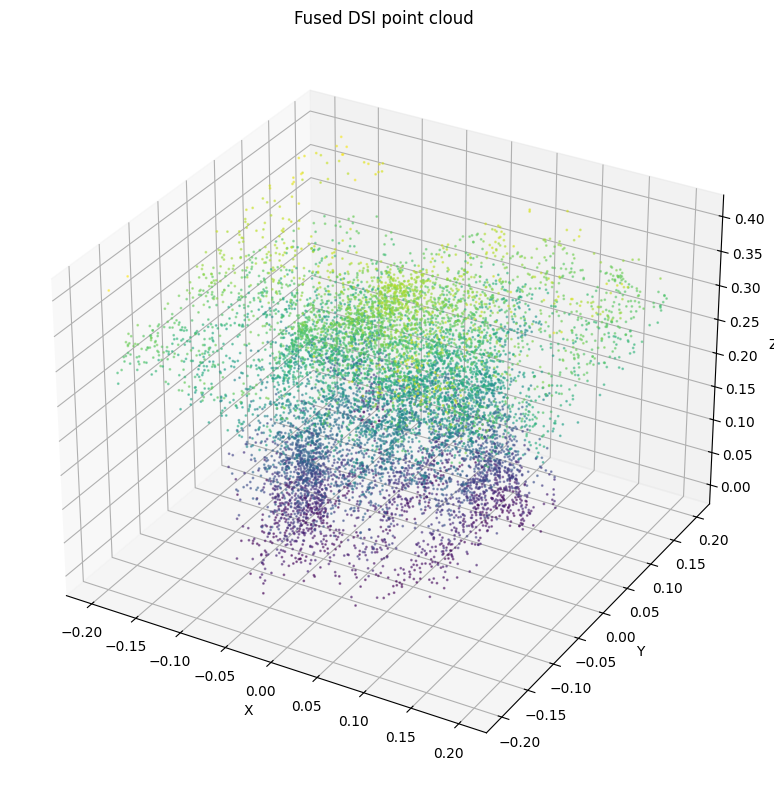

Saved 130,735 points to dsi_pointcloud.ply


In [17]:
# Remove outliers — points outside the expected bounding box
mask = (
    (np.abs(points_fused[:,0]) < 0.20) &
    (np.abs(points_fused[:,1]) < 0.20) &
    (points_fused[:,2] > 0.0) &
    (points_fused[:,2] < 0.45)
)
points_clean = points_fused[mask]
print(f"After bbox filter: {len(points_clean):,}")

# Optional: statistical outlier removal
from sklearn.neighbors import NearestNeighbors
nbrs = NearestNeighbors(n_neighbors=10).fit(points_clean)
dists, _ = nbrs.kneighbors(points_clean)
mean_dist = dists[:,1:].mean(axis=1)
threshold = mean_dist.mean() + 2*mean_dist.std()
points_clean = points_clean[mean_dist < threshold]
print(f"After outlier removal: {len(points_clean):,}")

# Visualise
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')
idx = np.random.choice(len(points_clean), min(10000, len(points_clean)), replace=False)
ax.scatter(points_clean[idx,0], points_clean[idx,1], points_clean[idx,2],
           s=1, c=points_clean[idx,2], cmap='viridis', alpha=0.5)
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_title('Fused DSI point cloud')
plt.tight_layout()
plt.show()

# Save as PLY
def save_ply(filename, points):
    with open(filename, 'w') as f:
        f.write(f"ply\nformat ascii 1.0\nelement vertex {len(points)}\n")
        f.write("property float x\nproperty float y\nproperty float z\nend_header\n")
        for p in points:
            f.write(f"{p[0]:.6f} {p[1]:.6f} {p[2]:.6f}\n")
    print(f"Saved {len(points):,} points to {filename}")

save_ply("dsi_pointcloud.ply", points_clean)